In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np
import random
import platform
import timm

## Dependencies
  - python=3.12
  - pytorch
  - torchvision
  - torchaudio
  - pytorch-cuda=11.8
  - jupyter
  - scikit-learn
  - matplotlib
  - seaborn
  - pillow
  - numpy

## For Reproducibility


In [6]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## Hardware specifications

In [9]:
if torch.cuda.is_available(): # For computers with NVIDIA GPU
    !nvidia-smi
elif torch.backends.mps.is_available(): # For macOS with Apple Silicon (M1/M2/M3)
    print("MPS (Apple Silicon GPU) is available.")
    print("macOS Version:", platform.mac_ver()[0])
    print("Torch MPS support:", torch.backends.mps.is_available())
else:
    print("No GPU detected. Using CPU.")


MPS (Apple Silicon GPU) is available.
macOS Version: 15.3.2
Torch MPS support: True


In [11]:
# --- DEVICE ---
if torch.cuda.is_available():
    device = torch.device("cuda")  # NVIDIA GPU
elif torch.backends.mps.is_available():
    device = torch.device("mps")   # Apple M1/M2/M3/M4 GPU
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


## Preprocessing helmet image dataset

In [14]:
# --- SETTINGS ---
dataset_path = "../../dataset/helmet_dataset_v2"
image_size = 320
print(os.listdir(dataset_path))

['.DS_Store', 'not_looking', 'looking']


In [16]:
# --- SAFETY LOADER ---
def pil_loader(path):
    with open(path, 'rb') as f:
        img = Image.open(f)
        return img.convert('RGB')

In [18]:
# --- TRANSFORM ---
train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),              # Resize slightly bigger
    transforms.CenterCrop(image_size-20),                     # Crop to model input
    transforms.RandomHorizontalFlip(p=0.5),                   # Good if left/right isn’t label-dependent
    transforms.RandomRotation(10),                            # Small tilt variation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.CenterCrop(300),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

**Resizing and Center Crop** - Expand to 320 x 320 then center crop (300px) to get the desired pixels (the helmets). Furthermore, is done to ensure consistent input dimensions for the CNN reduces computational load.

**RandomHorizontalFlip** - This simulates real-world variations (e.g., helmet on left/right side) and helps the model generalize better. Also, since  orientation doesn't affect the label. 

**Random Rotation** - This makes the model more robust to viewpoint changes in real-world usage.

**Normalization** - We used ImageNet-standard mean and standard deviation for normalization. This centers the input distributions and improves training convergence. Even though we trained from scratch, these values are widely used and provide good baseline behavior.

**ToTensor()** - So that the images are compatible with PyTorch

For the **Validation Set** we do not apply augmentation but just resizing and normalization for consistent evaluation without any artifical modifications.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


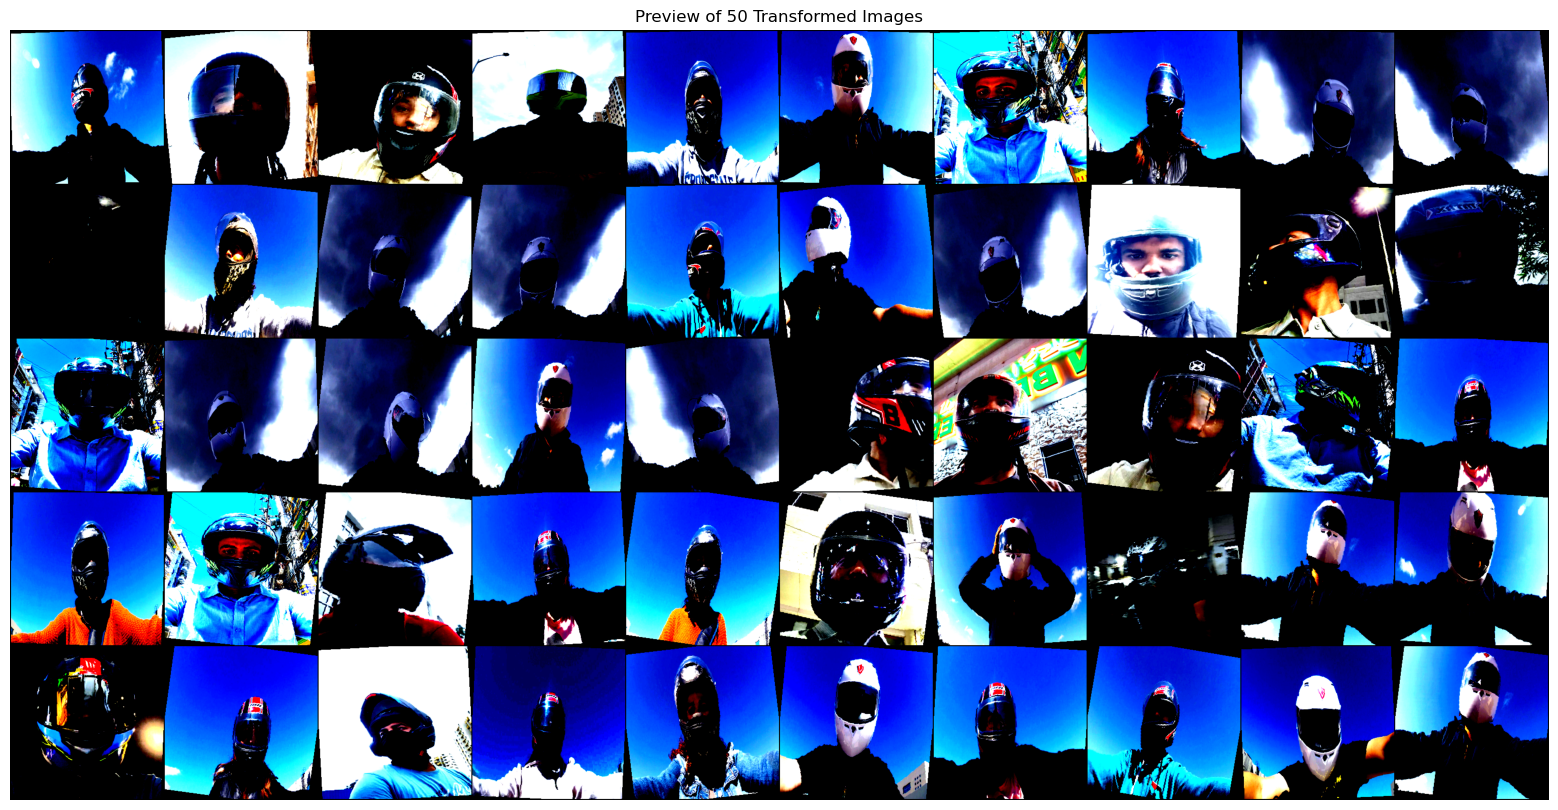

In [21]:
import torchvision

# Load dataset with transform applied
preview_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=train_transform,
    loader=pil_loader
)

# Create a DataLoader (no shuffling)
preview_loader = DataLoader(preview_dataset, batch_size=50, shuffle=True)

# Get one batch
images, labels = next(iter(preview_loader))

# Make a grid of 50 images (5 rows × 10 columns)
grid_img = torchvision.utils.make_grid(images[:50], nrow=10, padding=2)

# Unnormalize if needed (for display only)
np_img = grid_img.permute(1, 2, 0).numpy()

# Show the image grid
plt.figure(figsize=(20, 10))
plt.imshow(np_img)
plt.axis('off')
plt.title("Preview of 50 Transformed Images")
plt.show()

## Preparing Dataset

In [23]:
import shutil

# Delete any .ipynb_checkpoints inside helmet_dataset
checkpoints_path = os.path.join(dataset_path, ".ipynb_checkpoints")
if os.path.exists(checkpoints_path):
    shutil.rmtree(checkpoints_path)
    print("Removed .ipynb_checkpoints folder.")

In [56]:
from collections import Counter

print("Total images:", len(dataset))

classes = dataset.classes
targets = dataset.targets  # This is a list of class indices (0, 1, ...)

# Count number of images per class
class_counts = Counter(targets)

# Print detailed per-class info
print("Image counts per class:")
for cls_idx, count in class_counts.items():
    class_name = classes[cls_idx]
    print(f"  {class_name} ({cls_idx}): {count} images")

Total images: 1799
Image counts per class:
  looking (0): 899 images
  not_looking (1): 900 images


In [58]:
from sklearn.model_selection import StratifiedShuffleSplit
from collections import Counter

targets = dataset.targets  # From ImageFolder

In [60]:
# Custom wrapper to apply transform after subset
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        image = self.transform(image)
        return image, label

    def __len__(self):
        return len(self.subset)

## Using EfficientNet Model and Freezing First Layers

In [63]:
import torch.nn as nn
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

class EfficientNetB3PartialFineTune(nn.Module):
    def __init__(self, num_classes=2, freeze_until='6'):
        super(EfficientNetB3PartialFineTune, self).__init__()
        weights = EfficientNet_B3_Weights.DEFAULT
        self.backbone = efficientnet_b3(weights=weights)

        # Freeze all layers
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Unfreeze the last few blocks
        for name, module in self.backbone.features.named_children():
            if name >= freeze_until:
                for param in module.parameters():
                    param.requires_grad = True

        # Replace classifier
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier[1] = nn.Linear(in_features, num_classes)

        # Always allow the classifier to be trainable
        for param in self.backbone.classifier.parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.backbone(x)

## Preparing Smaller Dataset for Fine tuning

In [82]:
from collections import defaultdict
from torch.utils.data import Subset
import random

# Group image indices by class
label_to_indices = defaultdict(list)
for idx, label in enumerate(dataset.targets):
    label_to_indices[label].append(idx)

# Randomly sample 250 from each class (0 and 1)
random.seed(42)
small_idx = random.sample(label_to_indices[0], 250) + random.sample(label_to_indices[1], 250)

# Shuffle the combined indices
random.shuffle(small_idx)

# Create the small dataset
small_dataset = Subset(dataset, small_idx)

# Verify the class counts
subset_labels = [dataset.targets[i] for i in small_idx]
print("Small subset size:", len(small_dataset))
print("Class counts:", Counter(subset_labels))


Small subset size: 500
Class counts: Counter({1: 250, 0: 250})


In [84]:
small_targets = [dataset.targets[i] for i in small_dataset.indices]

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)

for train_idx, val_idx in splitter.split(np.zeros(len(small_targets)), small_targets):
    train_dataset = torch.utils.data.Subset(small_dataset, train_idx)
    val_dataset = torch.utils.data.Subset(small_dataset, val_idx)

In [86]:
# Apply transforms
train_dataset = TransformedSubset(train_dataset, train_transform)
val_dataset = TransformedSubset(val_dataset, val_transform)

## Fine tuning using Grid Search

In [89]:
from itertools import product
import time

torch.manual_seed(42)
np.random.seed(42)

def train_model(model, train_loader, criterion, optimizer, epochs=5):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss:.4f}")
    return model

def evaluate_model(model, val_loader, criterion):
    model.eval()
    correct, total = 0, 0
    total_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    accuracy = correct / total
    avg_loss = total_loss / len(val_loader)
    return accuracy, avg_loss

In [93]:
from torchvision.models import EfficientNet_B3_Weights
from torch.utils.data import DataLoader
from itertools import product
import time

param_grid = {
    "batch_size": [8, 16, 32], # 64 batch size stops with EfficientNet, overloads GPU memory
    "lr": [0.01, 0.001, 0.0001],
}

all_params = list(product(*param_grid.values()))
param_names = list(param_grid.keys())

results = []

for params in all_params:
    config = dict(zip(param_names, params))
    print(f"\nRunning config: {config}")
    
    # Data loaders
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'])

    # Model, loss, optimizer
    model = EfficientNetB3PartialFineTune(num_classes=2, freeze_until='6').to(device)
    criterion = nn.CrossEntropyLoss()
    
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=config['lr'])

    # Train and evaluate
    start = time.time()
    trained_model = train_model(model, train_loader, criterion, optimizer, epochs=10)
    val_acc, val_loss = evaluate_model(trained_model, val_loader, criterion)
    end = time.time()

    print(f"Val Acc: {val_acc:.4f} | Val Loss: {val_loss:.4f} | Time: {end-start:.2f}s")
    results.append({
        'lr': config['lr'],
        'batch_size': config['batch_size'],
        'val_acc': val_acc,
        'val_loss': val_loss
    })



Running config: {'batch_size': 8, 'lr': 0.01}
Epoch 1/10 - Loss: 53.2367
Epoch 2/10 - Loss: 49.3878
Epoch 3/10 - Loss: 31.7293
Epoch 4/10 - Loss: 20.1740
Epoch 5/10 - Loss: 13.5826
Epoch 6/10 - Loss: 13.7228
Epoch 7/10 - Loss: 8.4472
Epoch 8/10 - Loss: 10.7957
Epoch 9/10 - Loss: 7.1151
Epoch 10/10 - Loss: 8.9055
Val Acc: 0.9200 | Val Loss: 0.2276 | Time: 108.35s

Running config: {'batch_size': 8, 'lr': 0.001}
Epoch 1/10 - Loss: 20.9376
Epoch 2/10 - Loss: 11.4803
Epoch 3/10 - Loss: 10.0159
Epoch 4/10 - Loss: 7.9643
Epoch 5/10 - Loss: 7.5684
Epoch 6/10 - Loss: 7.3321
Epoch 7/10 - Loss: 5.5223
Epoch 8/10 - Loss: 4.3081
Epoch 9/10 - Loss: 3.9725
Epoch 10/10 - Loss: 6.1812
Val Acc: 0.9267 | Val Loss: 0.2985 | Time: 110.83s

Running config: {'batch_size': 8, 'lr': 0.0001}
Epoch 1/10 - Loss: 26.9072
Epoch 2/10 - Loss: 14.9482
Epoch 3/10 - Loss: 12.8217
Epoch 4/10 - Loss: 8.7139
Epoch 5/10 - Loss: 7.0754
Epoch 6/10 - Loss: 7.2805
Epoch 7/10 - Loss: 5.9761
Epoch 8/10 - Loss: 3.2048
Epoch 9/10 

In [95]:
print("\nGrid Search Summary (Highest Val. Accuracy to Lowest):")
for r in sorted(results, key=lambda x: x['val_acc'], reverse=True):
    print(f"Acc: {r['val_acc']:.4f} | Loss: {r['val_loss']:.4f} | LR: {r['lr']} | Batch: {r['batch_size']}")


Grid Search Summary (Highest Val. Accuracy to Lowest):
Acc: 0.9400 | Loss: 0.2873 | LR: 0.001 | Batch: 16
Acc: 0.9333 | Loss: 0.5673 | LR: 0.01 | Batch: 16
Acc: 0.9267 | Loss: 0.2985 | LR: 0.001 | Batch: 8
Acc: 0.9267 | Loss: 0.3909 | LR: 0.01 | Batch: 32
Acc: 0.9267 | Loss: 0.2603 | LR: 0.001 | Batch: 32
Acc: 0.9200 | Loss: 0.2276 | LR: 0.01 | Batch: 8
Acc: 0.9067 | Loss: 0.2217 | LR: 0.0001 | Batch: 16
Acc: 0.9000 | Loss: 0.1954 | LR: 0.0001 | Batch: 8
Acc: 0.8733 | Loss: 0.2605 | LR: 0.0001 | Batch: 32


In [97]:
best = max(results, key=lambda x: x['val_acc'])
print(f"\nBest Config: {best}")


Best Config: {'lr': 0.001, 'batch_size': 16, 'val_acc': 0.94, 'val_loss': 0.2873069863780984}


## Training the model with best hyperparameter

Using the whole dataset to train the model with the best hyperparameter.

**Model**: EfficientNetB3 (Freezing first 5 layers)

Final Hyperparameters:
* Learning Rate: 0.001
* Batch Size: 16
* Epochs: 20
* Patience: 5
* Weight decay: 1e-4
* Optimizer: Adam
* Loss Function: CrossEntropyLoss

In [100]:
best_config = {
    'lr': 0.001,
    'optimizer': 'Adam',
    'batch_size': 16,
    'epochs': 20,
    'patience': 5,
    'weight_decay': 1e-4
}

In [102]:
# Prepare full dataset, dividing into testing and training.
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)

for train_idx, val_idx in splitter.split(np.zeros(len(targets)), targets):
    train_dataset = torch.utils.data.Subset(dataset, train_idx)
    val_dataset = torch.utils.data.Subset(dataset, val_idx)

print("Train set size:", len(train_dataset))
print("Val set size:", len(val_dataset))

train_labels = [dataset.targets[i] for i in train_dataset.indices]
val_labels = [dataset.targets[i] for i in val_dataset.indices]
print("Train class counts:", Counter(train_labels))
print("Val class counts:", Counter(val_labels))

Train set size: 1259
Val set size: 540
Train class counts: Counter({1: 630, 0: 629})
Val class counts: Counter({0: 270, 1: 270})


In [104]:
# Apply transforms
full_train_dataset = TransformedSubset(train_dataset, train_transform)
full_val_dataset = TransformedSubset(val_dataset, val_transform)

In [106]:
train_loader = DataLoader(full_train_dataset, batch_size=best_config['batch_size'], shuffle=True)
val_loader = DataLoader(full_val_dataset, batch_size=best_config['batch_size'], shuffle=False)

In [108]:
model = EfficientNetB3PartialFineTune(num_classes=2, freeze_until="6").to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=best_config['lr'],
    weight_decay=best_config['weight_decay']
)

In [110]:
# --- METRICS TRACKING ---
train_losses = []
train_accuracies = []
val_accuracies = []
val_losses = []

In [112]:
def trainAndEval(epochs, patience):
    best_val_acc = 0.0
    patience_counter = 0
    best_epoch = 0
    best_model_state = None
    best_preds = []
    best_labels = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)

                _, predicted = torch.max(outputs, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = correct / total
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_acc)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {epoch_loss:.4f} - Train Acc: {epoch_acc:.4f} - Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.4f}")

        # Early stopping and best model saving
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_epoch = epoch + 1
            patience_counter = 0
            best_model_state = model.state_dict()
            best_preds = all_preds
            best_labels = all_labels
        else:
            patience_counter += 1
            print(f"No improvement. Patience: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    return best_model_state, best_epoch, best_val_acc, best_preds, best_labels

best_model_state, best_epoch, best_val_acc, best_preds, best_labels = trainAndEval(epochs=20, patience=5)

Epoch 1/20 - Train Loss: 0.3212 - Train Acc: 0.8737 - Val Loss: 0.2344 - Val Acc: 0.9019
Epoch 2/20 - Train Loss: 0.1845 - Train Acc: 0.9333 - Val Loss: 0.1498 - Val Acc: 0.9481
Epoch 3/20 - Train Loss: 0.1580 - Train Acc: 0.9523 - Val Loss: 0.1385 - Val Acc: 0.9389
No improvement. Patience: 1/5
Epoch 4/20 - Train Loss: 0.0989 - Train Acc: 0.9682 - Val Loss: 0.1268 - Val Acc: 0.9481
No improvement. Patience: 2/5
Epoch 5/20 - Train Loss: 0.1212 - Train Acc: 0.9635 - Val Loss: 0.0940 - Val Acc: 0.9611
Epoch 6/20 - Train Loss: 0.0682 - Train Acc: 0.9754 - Val Loss: 0.1606 - Val Acc: 0.9574
No improvement. Patience: 1/5
Epoch 7/20 - Train Loss: 0.0740 - Train Acc: 0.9746 - Val Loss: 0.2123 - Val Acc: 0.9426
No improvement. Patience: 2/5
Epoch 8/20 - Train Loss: 0.0674 - Train Acc: 0.9786 - Val Loss: 0.1497 - Val Acc: 0.9426
No improvement. Patience: 3/5
Epoch 9/20 - Train Loss: 0.0621 - Train Acc: 0.9809 - Val Loss: 0.1696 - Val Acc: 0.9519
No improvement. Patience: 4/5
Epoch 10/20 - Train

## Evaluation and Anaylsis

In [119]:
from sklearn.metrics import classification_report

model.load_state_dict(best_model_state)

print(f"\nBest Epoch: {best_epoch} | Val Accuracy: {best_val_acc:.2f}%")

print("\nClassification Report (Best Epoch):")
print(classification_report(best_labels, best_preds, target_names=dataset.classes))


Best Epoch: 5 | Val Accuracy: 0.96%

Classification Report (Best Epoch):
              precision    recall  f1-score   support

     looking       0.96      0.96      0.96       270
 not_looking       0.96      0.96      0.96       270

    accuracy                           0.96       540
   macro avg       0.96      0.96      0.96       540
weighted avg       0.96      0.96      0.96       540



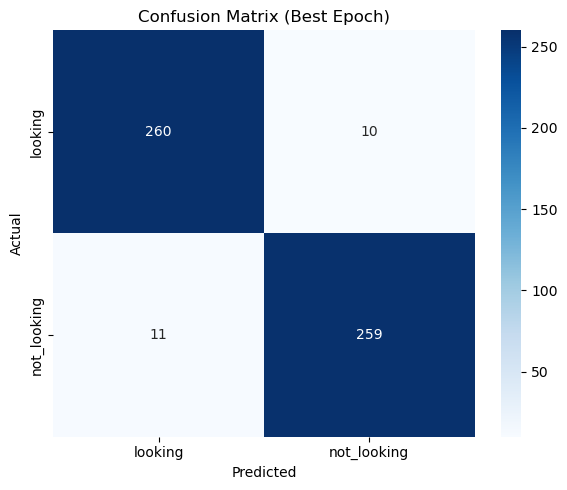

In [120]:
# --- CONFUSION MATRIX ---
cm = confusion_matrix(best_labels, best_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dataset.classes,
            yticklabels=dataset.classes)
plt.title("Confusion Matrix (Best Epoch)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

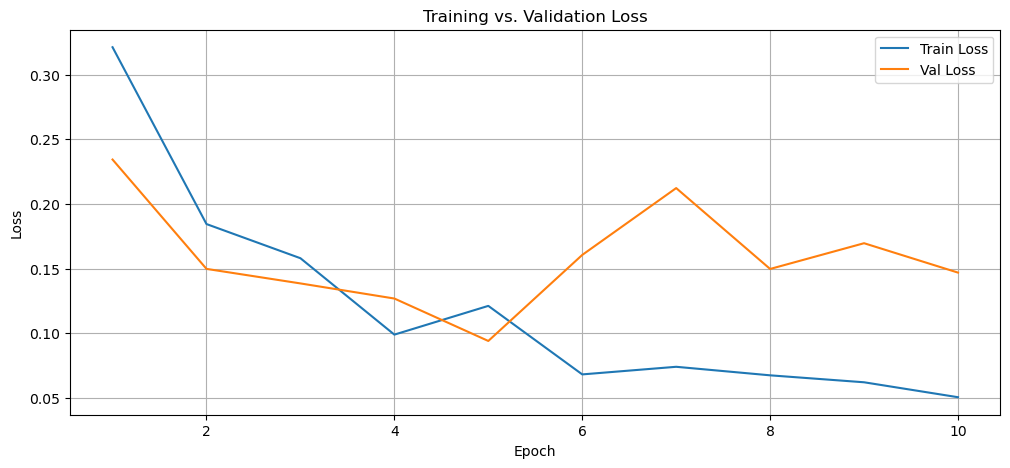

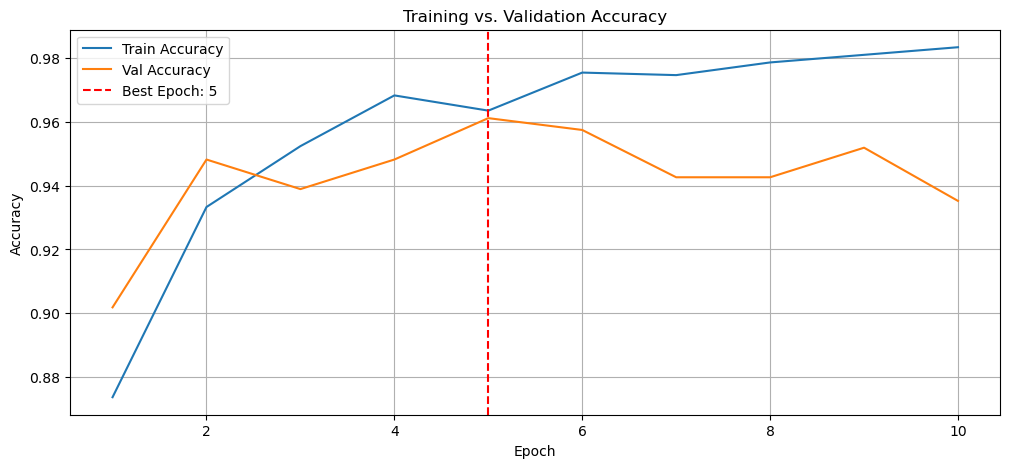

In [124]:
# generate x-axis epoch numbers starting from 1
epochs_range = range(1, len(train_accuracies) + 1)

# --- Loss Plot ---
plt.figure(figsize=(12, 5))
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs. Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# --- Accuracy Plot ---
plt.figure(figsize=(12, 5))
plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
plt.plot(epochs_range, val_accuracies, label='Val Accuracy')
plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Epoch: {best_epoch}')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs. Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

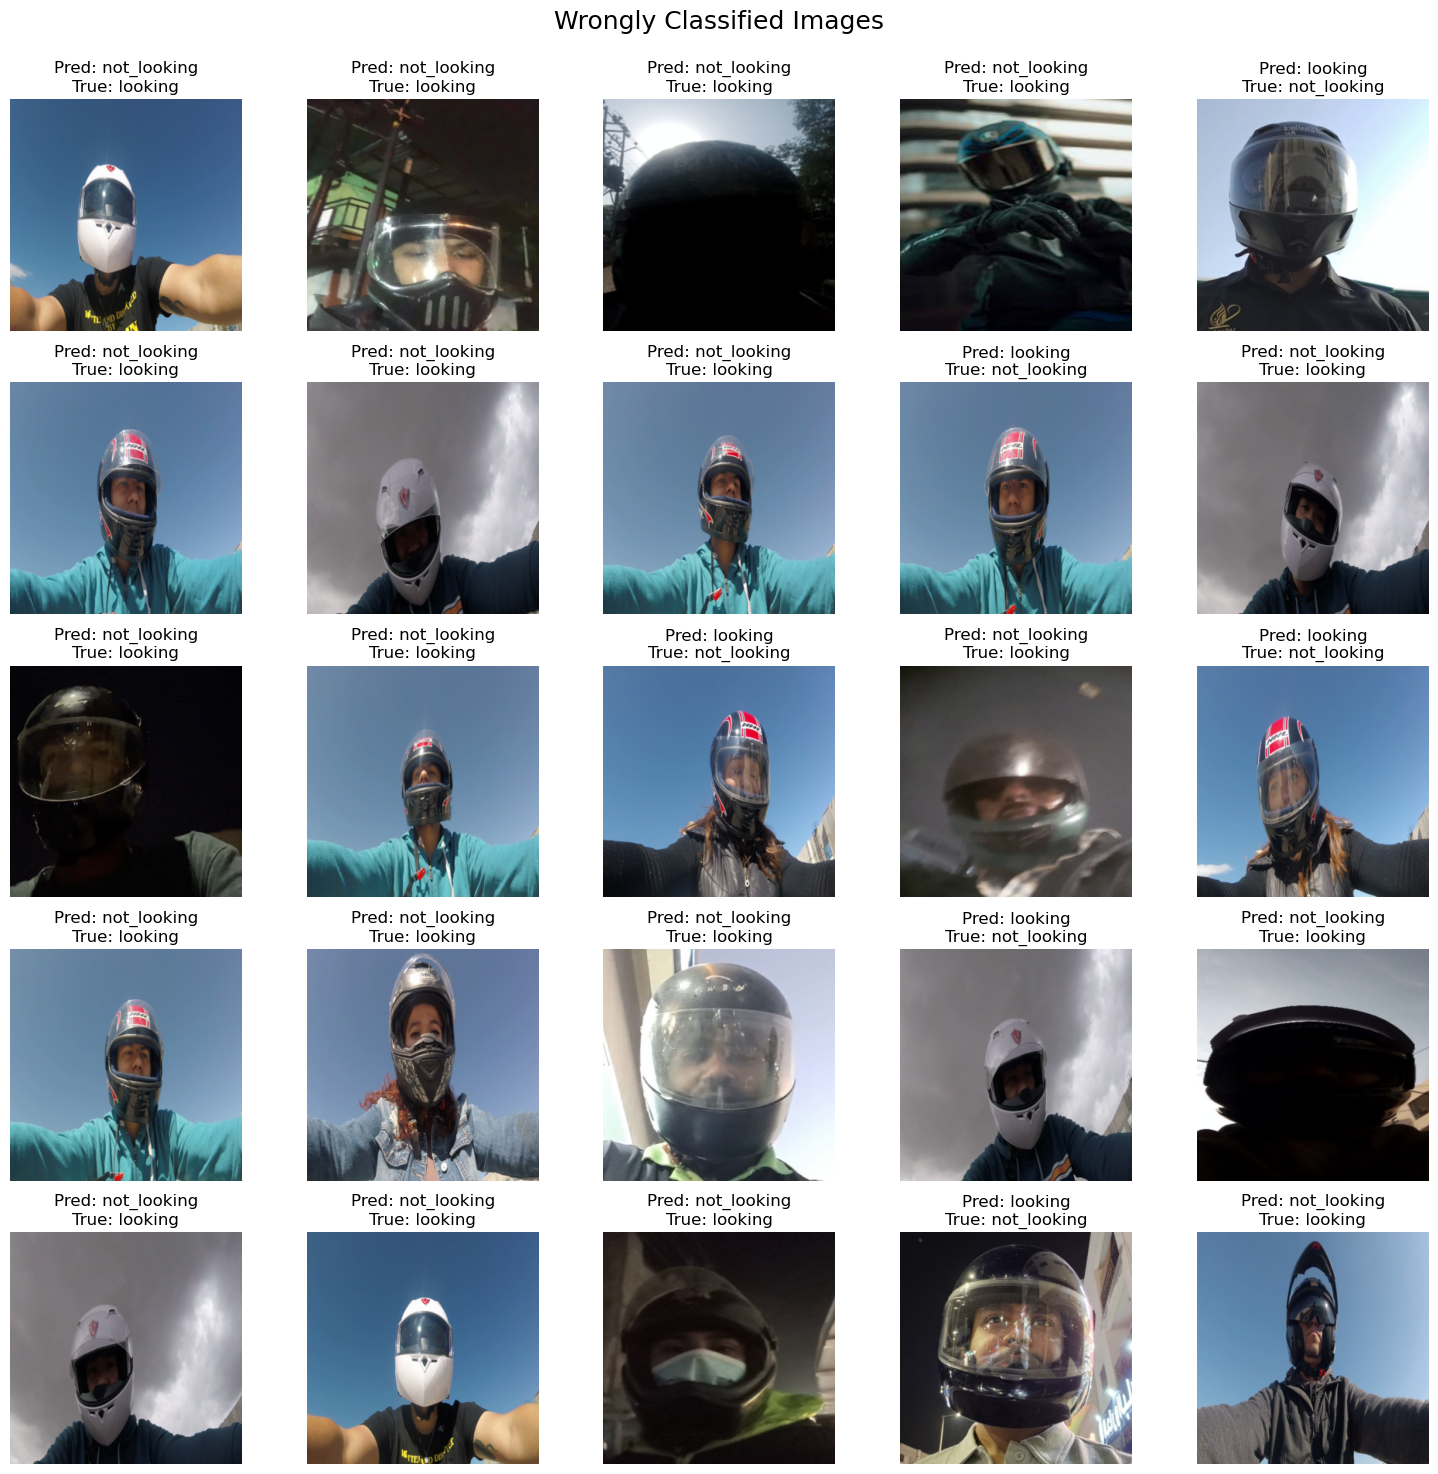

In [125]:
misclassified = []
model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        for img, pred, true in zip(images, preds, labels):
            if pred != true:
                misclassified.append((img.cpu(), pred.item(), true.item()))

plt.figure(figsize=(15, 15))
for idx, (img, pred, true) in enumerate(misclassified[:25]):
    img = img.permute(1, 2, 0).numpy()
    img = (img * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
    img = np.clip(img, 0, 1)
    plt.subplot(5, 5, idx + 1)
    plt.imshow(img)
    plt.title(f"Pred: {dataset.classes[pred]}\nTrue: {dataset.classes[true]}")
    plt.axis('off')
plt.tight_layout()
plt.suptitle("Wrongly Classified Images", fontsize=18)
plt.subplots_adjust(top=0.92)
plt.show()

In [35]:
torch.save(model.state_dict(), "efficientNetB3.pth")